## Análisis de rendimiento: definición de "temporada buena vs mala"

Este notebook parte de `df_maestro.csv`, ya construido y validado en `01_exploracion_estructura.ipynb`. Aquí se define una métrica compuesta de rendimiento por temporada y se realiza el análisis exploratorio de la relación entre gasto, entrenador y rendimiento.

### Decisión de diseño: qué define una "temporada buena"

El fútbol es un deporte resultadista: el objetivo de cada temporada no es alcanzar una cifra específica de puntos, es terminar por delante del resto de la liga. Por eso, la categoría de éxito/fracaso de una temporada (`categoria_temporada`) se define exclusivamente por **posición final**, no por puntos.

Además, la escala se ajusta al contexto específico del Barça, no a un estándar genérico de club de mitad de tabla: para un club de esta escala, no clasificar a Champions League ya representa una temporada fallida, no hay una zona "aceptable" intermedia entre pelear el título y quedar fuera de Europa.

- **Título**: posición 1
- **Top 4**: posición 2 a 4 (zona de clasificación directa a Champions League)
- **Mala**: posición 5 a 8 (fuera de Champions, pero probablemente todavía dentro de zona de competición europea menor, Europa League o Conference League)
- **Catastrófico**: posición 9 en adelante (fuera de toda competición europea, sin nada que pelear el resto de la temporada)

En paralelo, se calcula `rendimiento_relativo`, una variable continua (puntos obtenidos sobre el máximo de puntos posible esa temporada específica). Esta normalización es necesaria porque los puntos crudos no son comparables entre eras: la regla de puntos por victoria cambió de 2 a 3 en 1995/96, y dos temporadas (1995/96 y 1996/97) tuvieron 42 partidos en vez de 38. `rendimiento_relativo` corrige ambas diferencias sin modificar el dato base de puntos, que se mantiene fiel a la clasificación real de cada año.

**Uso previsto de cada variable:** `categoria_temporada` se usa para comparaciones narrativas y visualizaciones (por ejemplo, cuántas temporadas de título tuvo cada entrenador). `rendimiento_relativo` se usa para análisis estadístico que requiere una variable numérica continua, como la correlación entre gasto neto y rendimiento. No se usa gasto ni entrenador como parte de la definición de "temporada buena", para evitar que el criterio de éxito quede contaminado por las mismas variables que después se van a analizar en relación a él.

In [14]:
import pandas as pd

df_maestro = pd.read_csv('../data/processed/df_maestro.csv', dtype={'temporada': str})
df_maestro.head()

,temporada,posicion,puntos,partidos_jugados,victorias,empates,derrotas,goles_favor,goles_contra,diferencia_gol,anio_inicio,entrenador_principal,hubo_cambio_entrenador,gasto_compras,ingreso_ventas,gasto_neto,datos_gasto_disponibles
0,9394,1,56,38,25,6,7,91,42,49,1993,Johan Cruyff,False,NaN,NaN,NaN,False
1,9495,4,46,38,18,10,10,60,45,15,1994,Johan Cruyff,False,NaN,NaN,NaN,False
2,9596,3,80,42,22,14,6,72,39,33,1995,Johan Cruyff,True,NaN,NaN,NaN,False
3,9697,2,90,42,28,6,8,102,48,54,1996,Bobby Robson,False,NaN,NaN,NaN,False
4,9798,1,74,38,23,5,10,78,56,22,1997,Louis van Gaal,False,NaN,NaN,NaN,False


In [15]:
df_maestro['puntos_por_victoria'] = df_maestro['temporada'].apply(lambda t: 2 if t in ['9394', '9495'] else 3)
df_maestro['puntos_maximos_posibles'] = df_maestro['partidos_jugados'] * df_maestro['puntos_por_victoria']
df_maestro['rendimiento_relativo'] = df_maestro['puntos'] / df_maestro['puntos_maximos_posibles']

df_maestro[['temporada', 'posicion', 'puntos', 'puntos_maximos_posibles', 'rendimiento_relativo']].head(10)

,temporada,posicion,puntos,puntos_maximos_posibles,rendimiento_relativo
0,9394,1,56,76,0.736842
1,9495,4,46,76,0.605263
2,9596,3,80,126,0.634921
3,9697,2,90,126,0.714286
4,9798,1,74,114,0.649123
5,9899,1,79,114,0.692982
6,9900,2,64,114,0.561404
7,0001,4,63,114,0.552632
8,0102,4,64,114,0.561404
9,0203,6,56,114,0.491228


In [16]:
def categorizar_temporada(posicion):
    if posicion == 1:
        return 'Título'
    elif posicion <= 4:
        return 'Top 4'
    elif posicion <= 8:
        return 'Mala'
    else:
        return 'Catastrófico'

df_maestro['categoria_temporada'] = df_maestro['posicion'].apply(categorizar_temporada)
df_maestro['categoria_temporada'].value_counts()

categoria_temporada
Título    16
Top 4     16
Mala       1
Name: count, dtype: int64

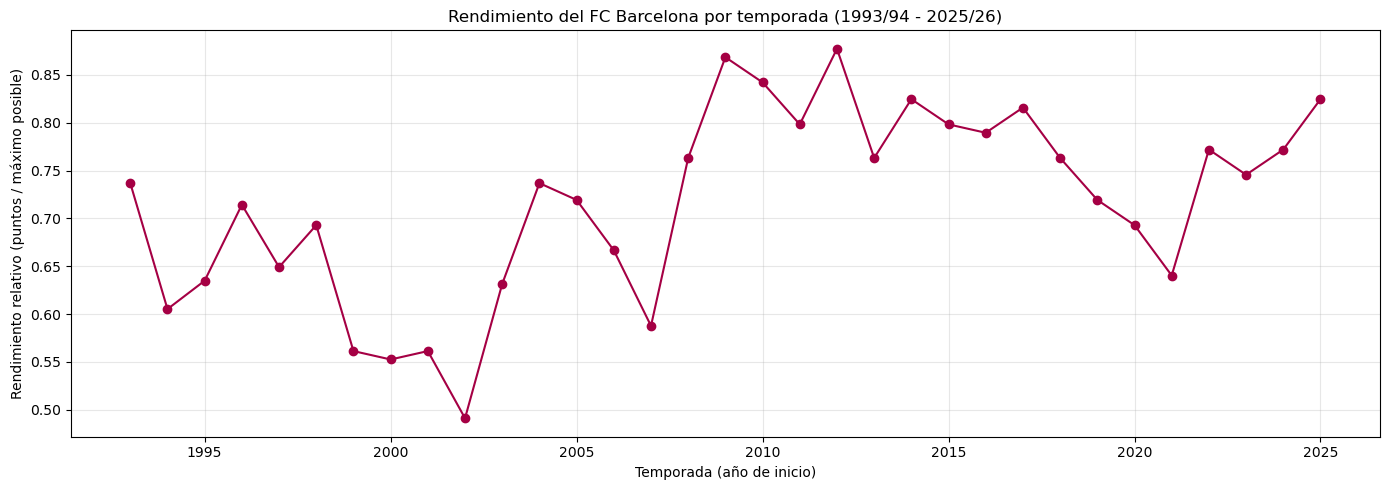

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_maestro['anio_inicio'], df_maestro['rendimiento_relativo'], marker='o', color='#a50044')
ax.set_xlabel('Temporada (año de inicio)')
ax.set_ylabel('Rendimiento relativo (puntos / máximo posible)')
ax.set_title('Rendimiento del FC Barcelona por temporada (1993/94 - 2025/26)')
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig.savefig('../reports/figures/rendimiento_por_temporada.png', dpi=150, bbox_inches='tight')
plt.show()

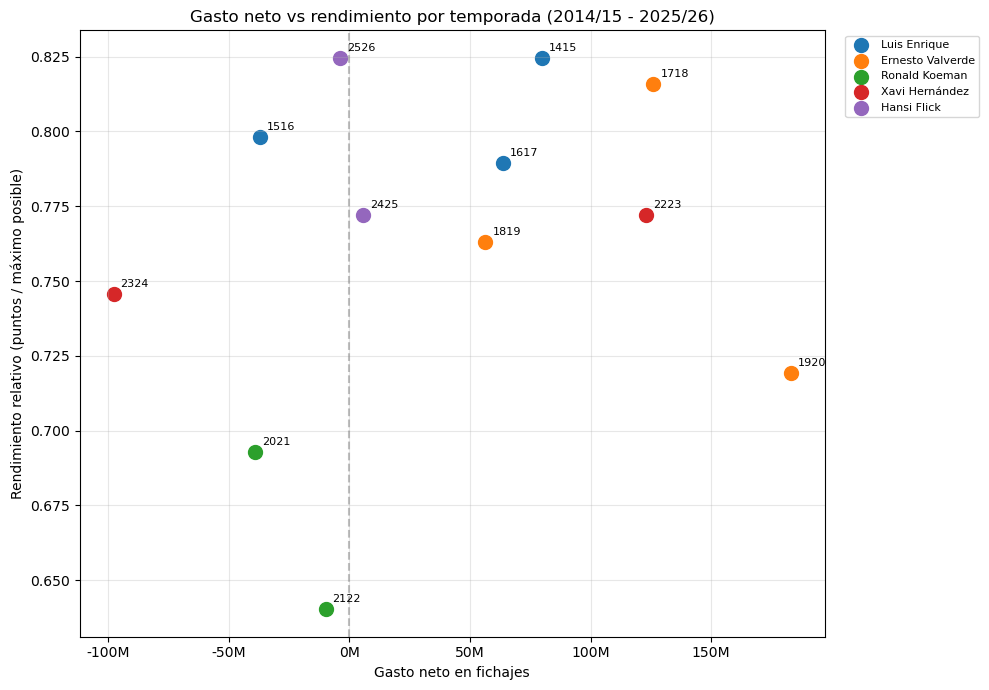

In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

df_con_gasto = df_maestro[df_maestro['datos_gasto_disponibles'] == True].copy()

fig, ax = plt.subplots(figsize=(10, 7))

entrenadores_unicos = df_con_gasto['entrenador_principal'].unique()
colores = plt.cm.tab10(range(len(entrenadores_unicos)))
mapa_color = dict(zip(entrenadores_unicos, colores))

for entrenador in entrenadores_unicos:
    subset = df_con_gasto[df_con_gasto['entrenador_principal'] == entrenador]
    ax.scatter(subset['gasto_neto'], subset['rendimiento_relativo'],
               label=entrenador, color=mapa_color[entrenador], s=100)

for _, fila in df_con_gasto.iterrows():
    ax.annotate(fila['temporada'], (fila['gasto_neto'], fila['rendimiento_relativo']),
                fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Gasto neto en fichajes')
ax.set_ylabel('Rendimiento relativo (puntos / máximo posible)')
ax.set_title('Gasto neto vs rendimiento por temporada (2014/15 - 2025/26)')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig.savefig('../reports/figures/gasto_vs_rendimiento.png', dpi=150, bbox_inches='tight')
plt.show()

### Análisis conjunto: rendimiento histórico y su relación con el gasto

**Sobre el rendimiento en el rango completo (1993/94-2025/26):** el patrón muestra tres eras claramente diferenciadas, visibles sin necesidad de ningún cruce adicional: una etapa de inestabilidad en el banquillo entre 1994 y 2003 (valle mínimo en 2001/02, bajo Rexach, tras el cambio de entrenador a mitad de la temporada anterior), la era dorada de Guardiola-Vilanova entre 2008 y 2013 (meseta más alta y sostenida del rango, con el pico absoluto en 2012/13), y una recuperación reciente desde 2021/22 en adelante tras la crisis institucional de la etapa Koeman.

**Sobre gasto vs rendimiento (2014/15-2025/26):** el gasto neto en fichajes no predice el rendimiento de forma directa. La temporada de mayor rendimiento del conjunto (2025/26) tuvo gasto neto casi nulo, y la de mayor gasto (2019/20, ~183M) produjo uno de los rendimientos más bajos. En cambio, el entrenador sí muestra un agrupamiento más consistente: las temporadas de Luis Enrique se concentran en la zona alta de rendimiento con gasto moderado, mientras que ambas temporadas de Koeman caen en la zona baja, sin importar si esa temporada tuvo gasto positivo o negativo.

**Lectura combinada:** ambos gráficos apuntan en la misma dirección, aunque desde ángulos distintos. El primero muestra que las mejores rachas históricas del club coinciden con periodos de estabilidad y continuidad en el banquillo (Rijkaard, Guardiola-Vilanova), no necesariamente con los picos de inversión. El segundo, ya con el dato de gasto disponible, refuerza esa lectura: dentro del rango donde se puede medir, el entrenador parece separar mejor los grupos de rendimiento que el nivel de gasto. Esto es consistente con la hipótesis inicial del proyecto (que el entrenador puede pesar más que el dinero invertido), pero **no es una conclusión estadística todavía**, es una lectura visual sobre 12 puntos de datos. El siguiente paso lógico es calcular una correlación numérica real (coeficiente de Pearson) para cuantificar la fuerza de la relación gasto-rendimiento y evitar sacar conclusiones fuertes solo de la inspección visual.

In [20]:
from scipy.stats import pearsonr

correlacion, p_valor = pearsonr(df_con_gasto['gasto_neto'], df_con_gasto['rendimiento_relativo'])

print(f'Coeficiente de correlación (Pearson): {correlacion:.3f}')
print(f'Valor p: {p_valor:.3f}')

Coeficiente de correlación (Pearson): 0.207
Valor p: 0.520


### Correlación entre gasto neto y rendimiento

Se calculó el coeficiente de correlación de Pearson entre `gasto_neto` y `rendimiento_relativo` sobre las 12 temporadas con datos de gasto disponibles: **r = 0.207, p = 0.520**.

El coeficiente es positivo pero débil, y el valor p está muy por encima del umbral convencional de significancia estadística (0.05). Esto significa que **no se encontró evidencia estadísticamente significativa de una relación lineal entre gasto neto y rendimiento** en el rango de datos disponible. Es importante no sobre-interpretar este resultado: la ausencia de evidencia de relación no equivale a evidencia de que no existe relación, especialmente con una muestra de solo 12 temporadas, un tamaño pequeño que limita fuertemente el poder estadístico de cualquier prueba.

Esto es consistente con la lectura visual del gráfico de dispersión: los puntos no muestran una tendencia lineal clara, y el agrupamiento por entrenador se ve visualmente más marcado que el agrupamiento por nivel de gasto.

In [21]:
resumen_entrenadores = df_maestro.groupby('entrenador_principal').agg(
    temporadas=('temporada', 'count'),
    rendimiento_promedio=('rendimiento_relativo', 'mean'),
    titulos=('categoria_temporada', lambda x: (x == 'Título').sum())
).reset_index()

resumen_entrenadores = resumen_entrenadores.sort_values('rendimiento_promedio', ascending=False)
resumen_entrenadores

,entrenador_principal,temporadas,rendimiento_promedio,titulos
12,Tito Vilanova,1,0.877193,1
10,Pep Guardiola,4,0.817982,3
9,Luis Enrique,3,0.804094,2
5,Hansi Flick,2,0.798246,2
2,Ernesto Valverde,3,0.766082,2
4,Gerardo Martino,1,0.763158,0
13,Xavi Hernández,2,0.758772,1
0,Bobby Robson,1,0.714286,0
3,Frank Rijkaard,5,0.668421,2
11,Ronald Koeman,2,0.666667,0


In [24]:
resumen_confiable = resumen_entrenadores[resumen_entrenadores['temporadas'] >= 2].copy()
resumen_una_temporada = resumen_entrenadores[resumen_entrenadores['temporadas'] < 2].copy()

print('Entrenadores con 2+ temporadas:')
print(resumen_confiable)
print()
print('Entrenadores con 1 sola temporada (caso aislado, no se compara):')
print(resumen_una_temporada)

Entrenadores con 2+ temporadas:
   entrenador_principal  temporadas  rendimiento_promedio  titulos
10        Pep Guardiola           4              0.817982        3
9          Luis Enrique           3              0.804094        2
5           Hansi Flick           2              0.798246        2
2      Ernesto Valverde           3              0.766082        2
13       Xavi Hernández           2              0.758772        1
3        Frank Rijkaard           5              0.668421        2
11        Ronald Koeman           2              0.666667        0
6          Johan Cruyff           3              0.659009        1
8        Louis van Gaal           4              0.598684        2

Entrenadores con 1 sola temporada (caso aislado, no se compara):
    entrenador_principal  temporadas  rendimiento_promedio  titulos
12         Tito Vilanova           1              0.877193        1
4        Gerardo Martino           1              0.763158        0
0           Bobby Robson    

### Rendimiento promedio por entrenador (corte: 2+ temporadas)

Se recalculó el resumen separando entrenadores con 2 o más temporadas dirigidas (9 casos) de aquellos con una sola temporada (5 casos), estos últimos tratados como casos aislados, no comparables entre sí ni contra el resto.

**Nota sobre el corte elegido:** 2 temporadas no constituye una muestra estadísticamente robusta, pero sí permite descartar el caso más extremo de sesgo (una única temporada atípica dominando el promedio por completo). Es un umbral práctico, no un estándar estadístico riguroso, y se declara así explícitamente.

**Dentro del grupo de 2+ temporadas:**

- **Pep Guardiola lidera con claridad** (0.818 de rendimiento promedio, 3 títulos en 4 temporadas), consistente con toda la evidencia previa del proyecto.
- **Luis Enrique queda en segundo lugar, muy cerca de Guardiola** (0.804, 2 títulos en 3 temporadas), y **Hansi Flick tercero** (0.798, 2 títulos en solo 2 temporadas), un inicio de etapa muy fuerte, aunque con la muestra más chica del grupo, vale la pena revisar en el futuro si se sostiene con más datos.
- **Louis van Gaal tiene el rendimiento promedio más bajo del grupo** (0.599) pese a dirigir 4 temporadas (dos etapas distintas) y ganar 2 títulos, sugiriendo una gestión de resultados irregular más que una etapa sólida.
- **Ronald Koeman es el único entrenador de este grupo con 0 títulos** (0.667 de rendimiento, 2 temporadas), coherente con la conocida etapa de crisis institucional del club en ese periodo.
- **Frank Rijkaard, con la muestra más grande de todas (5 temporadas), queda en la mitad baja de la tabla** (0.668) pese a sus 2 títulos, reflejando una etapa de resultados mixtos: los años de mayor gloria (2005-2006) conviven con temporadas más flojas que bajan el promedio.

**Grupo de 1 sola temporada (no comparable):** destaca Tito Vilanova con el rendimiento más alto de todo el análisis (0.877), la temporada del récord de 100 puntos, un resultado extremo que ilustra bien por qué este grupo se trata aparte: una sola temporada extraordinaria no equivale a una etapa sostenida de éxito.

**Conclusión parcial:** el entrenador sigue mostrando una asociación más clara con la variación en rendimiento que el gasto neto (que no mostró correlación estadísticamente significativa). Sin embargo, con un máximo de 5 temporadas para el entrenador con mayor muestra del rango, ningún resultado de esta sección debe leerse como prueba causal definitiva, sino como evidencia descriptiva que refuerza la hipótesis inicial del proyecto.|

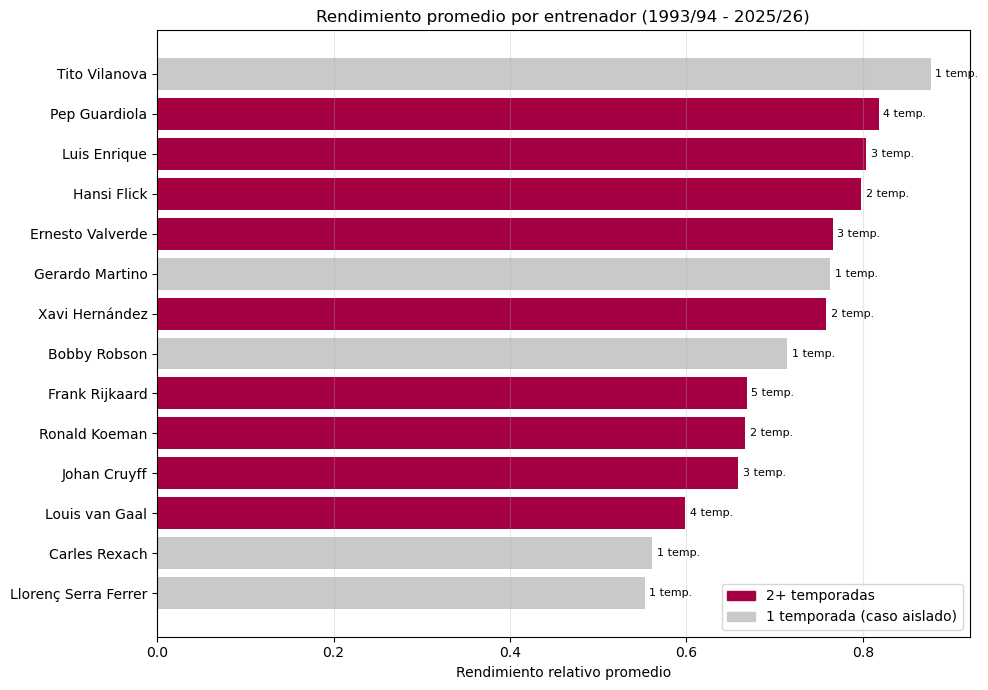

In [25]:
resumen_entrenadores['grupo'] = resumen_entrenadores['temporadas'].apply(
    lambda t: '2+ temporadas' if t >= 2 else '1 temporada (caso aislado)'
)

resumen_ordenado = resumen_entrenadores.sort_values('rendimiento_promedio', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

colores_barras = resumen_ordenado['grupo'].map({
    '2+ temporadas': '#a50044',
    '1 temporada (caso aislado)': '#c9c9c9'
})

ax.barh(resumen_ordenado['entrenador_principal'], resumen_ordenado['rendimiento_promedio'], color=colores_barras)

for i, (rendimiento, temporadas) in enumerate(zip(resumen_ordenado['rendimiento_promedio'], resumen_ordenado['temporadas'])):
    ax.text(rendimiento + 0.005, i, f'{temporadas} temp.', va='center', fontsize=8)

ax.set_xlabel('Rendimiento relativo promedio')
ax.set_title('Rendimiento promedio por entrenador (1993/94 - 2025/26)')
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
leyenda = [Patch(color='#a50044', label='2+ temporadas'), Patch(color='#c9c9c9', label='1 temporada (caso aislado)')]
ax.legend(handles=leyenda, loc='lower right')

plt.tight_layout()
fig.savefig('../reports/figures/rendimiento_por_entrenador.png', dpi=150, bbox_inches='tight')
plt.show()